# Mixed-type influence diagrams — a continuous test score

The library's headline case is a diagram that mixes **discrete** and
**continuous** chance variables while the decisions and utilities stay
discrete. This notebook builds one: the *Automated Logistics Center*.

An e-commerce company must choose between an advanced robotics system and a
conventional one, and it may run an expensive feasibility test first. In the
fully discrete version of the problem the test reports one of three
categories. Here the test instead measures a **continuous performance
score**, and the company acts on the score *binned* into
`bad` / `good` / `excellent`. The score is a real-valued chance node; the
report, the decisions and the payoff keep the discrete structure.

In [1]:
from _logistics_center import (
    induced_report_probs,
    pyagrum_solution,
    pylimid_diagram,
)

from pylimid import infer, solve

## The model

The shared module `_logistics_center.py` defines the whole diagram. Two
discrete chance roots (`advanced_state`, `conventional_state`), the `test`
decision, the continuous `score` (a Gamma whose mean depends on
`advanced_state`), the binned `report`, the `invest` decision — which
observes the report and remembers whether the test ran — and the payoff.

[]


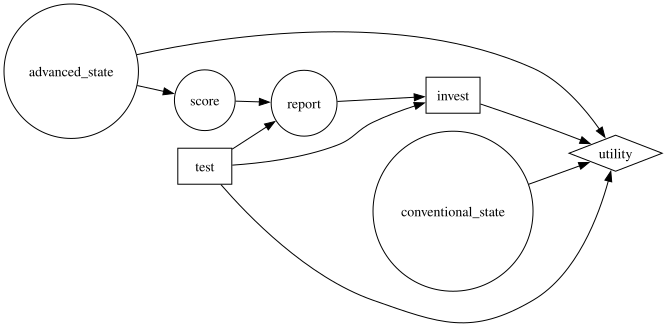

In [2]:
diag = pylimid_diagram()
print(diag.validate())
diag

## The continuous score, binned

`score | advanced_state` is Gamma with a per-state mean: a smooth system
scores high, a major-failure-prone one scores low. Cutting the score at two
thresholds — below 4 is `bad`, above 7 is `excellent` — induces the report
distribution the company actually sees. Because the score is a proper
continuous variable, `P(report | advanced_state)` is the Gamma CDF mass in
each bin, not a hand-written table.

In [3]:
labels = ("smooth", "minor", "major")
print("P(report | advanced_state)   bad    good   excellent")
for state, row in zip(labels, induced_report_probs(), strict=True):
    print(f"  {state:<7} {row[0]:8.3f} {row[1]:7.3f} {row[2]:10.3f}")

P(report | advanced_state)   bad    good   excellent


  smooth     0.001   0.278      0.721
  minor      0.157   0.811      0.032
  major      0.942   0.058      0.000


A smooth system is almost never `bad`; a major-failure-prone system is
almost always `bad` — the score carries real information about the true
state.

## Solving it

The continuous `score` never enters a decision's information set: `invest`
observes the discrete `report`, so the diagram is solved by the same
discrete-decision solver as any categorical LIMID. The scan enumerates the
`test` actions and the `invest` rule over its nine `(test, report)` cells.

In [4]:
solution = solve(diag, method="scan", num_samples=100_000)
print("method:", solution.method)
print("expected utility: €{:.2f}M".format(solution.expected_utility))
print("test decision:", solution.policy["test"])
print("invest given a report:")
for report, action in solution.policy["invest"].items():
    if report[0] == 0:
        print(
            f"  report={('bad', 'good', 'excellent')[report[1]]:<9} ->"
            f" {('advanced', 'conventional')[action]}"
        )

method: scan
expected utility: €94.42M
test decision: {(): 0}
invest given a report:
  report=bad       -> conventional
  report=good      -> advanced
  report=excellent -> advanced


The company should **run the test**, invest in the advanced system on a
`good` or `excellent` report, and fall back to the conventional system on a
`bad` one.

## The exact reference

pyAgrum's LIMID solver is exact but discrete. We can still check the answer:
integrate the continuous score out analytically — using the same
`P(report | advanced_state)` table above — to get an equivalent all-discrete
diagram, and solve *that* exactly. The two maximum expected utilities must
agree up to Monte-Carlo noise.

In [5]:
meu, exact_policy = pyagrum_solution()
print("pyAgrum exact MEU:      €{:.2f}M".format(meu))
print("scan estimate (100k):   €{:.2f}M".format(solution.expected_utility))
print("pyAgrum test decision: ", exact_policy["test"])
print("pyAgrum invest on the test branch:")
for report in range(3):
    print(
        f"  report={('bad', 'good', 'excellent')[report]:<9} ->"
        f" {('advanced', 'conventional')[exact_policy['invest'][(0, report)]]}"
    )

pyAgrum exact MEU:      €94.46M
scan estimate (100k):   €94.42M
pyAgrum test decision:  {(): 0}
pyAgrum invest on the test branch:
  report=bad       -> conventional
  report=good      -> advanced
  report=excellent -> advanced


## The continuous posterior

`infer()` works on the same diagram once every decision is bound. Observing
a `bad` report sharpens the belief about the true state and moves the
posterior of the continuous score down to the low-performing region — the
mixed chance variables infer together.

In [6]:
posterior = infer(
    diag,
    ["advanced_state", "score"],
    observed={"report": 0},
    policy={"test": 0, "invest": 1},
)
print(
    "P(advanced_state | report=bad):",
    [round(p, 3) for p in posterior["advanced_state"].marginal()],
)
print(
    "score | report=bad:  mean {:.2f}  std {:.2f}".format(
        posterior["score"].mean(), posterior["score"].std()
    )
)

P(advanced_state | report=bad): [0.009, 0.242, 0.75]
score | report=bad:  mean 3.08  std 0.56


The posterior over the state concentrates on `major`, and the continuous
score settles near the low end — exactly what a `bad` report should tell
us.